# **Course 2 Automatidata project**
**Course 2 - Go Beyond the Numbers: Translate Data into Insights**

You are the newest data professional in a fictional data consulting firm: Automatidata. The team is in an early stage of the project, having only just completed an initial plan of action and some early Python coding work. 

Luana Rodriquez, the senior data analyst at Automatidata, is pleased with the work you have already completed and requests your assistance with some EDA and data visualization work for the New York City Taxi and Limousine Commission project (New York City TLC) to get a general understanding of what taxi ridership looks like. The management team is asking for a Python notebook showing data structuring and cleaning, as well as any matplotlib/seaborn visualizations plotted to help understand the data. At the very least, include a box plot of the ride durations and some time series plots, like a breakdown by quarter or month. 

Additionally, the management team has recently asked all EDA to include Tableau visualizations. For this taxi data, create a Tableau dashboard showing a New York City map of taxi/limo trips by month. Make sure it is easy to understand to someone who isn’t data savvy, and remember that the assistant director at the New York City TLC is a person with visual impairments.

A notebook was structured and prepared to help you in this project. Please complete the following questions.

### Course 2 End-of-course project: Exploratory data analysis

In this activity, you will examine data provided and prepare it for analysis. You will also design a professional data visualization that tells a story, and will help data-driven decisions for business needs. 

Please note that the Tableau visualization activity is optional, and will not affect your completion of the course. Completing the Tableau activity will help you practice planning out and plotting a data visualization based on a specific business need. The structure of this activity is designed to emulate the proposals you will likely be assigned in your career as a data professional. Completing this activity will help prepare you for those career moments.

**The purpose** of this project is to conduct exploratory data analysis on a provided data set. Your mission is to continue the investigation you began in C1 and perform further EDA on this data with the aim of learning more about the variables. 
  
**The goal** is to clean data set and create a visualization.
<br/>  
*This activity has 4 parts:*

**Part 1:** Imports, links, and loading

**Part 2:** Data Exploration
*   Data cleaning


**Part 3:** Building visualizations

**Part 4:** Evaluate and share results

<br/> 
Follow the instructions and answer the questions below to complete the activity. Then, you will complete an Executive Summary using the questions listed on the PACE Strategy Document.

Be sure to complete this activity before moving on. The next course item will provide you with a completed exemplar to compare to your own work. 



# **Visualize a story in Tableau and Python**

# **PACE stages** 


<img src="images/Pace.png" width="100" height="100" align=left>

   *        [Plan](#scrollTo=psz51YkZVwtN&line=3&uniqifier=1)
   *        [Analyze](#scrollTo=mA7Mz_SnI8km&line=4&uniqifier=1)
   *        [Construct](#scrollTo=Lca9c8XON8lc&line=2&uniqifier=1)
   *        [Execute](#scrollTo=401PgchTPr4E&line=2&uniqifier=1)

Throughout these project notebooks, you'll see references to the problem-solving framework PACE. The following notebook components are labeled with the respective PACE stage: Plan, Analyze, Construct, and Execute.

<img src="images/Plan.png" width="100" height="100" align=left>


## PACE: Plan 

In this stage, consider the following questions where applicable to complete your code response:
1. Identify any outliers: 


*   What methods are best for identifying outliers?
*   How do you make the decision to keep or exclude outliers from any future models?



==> ENTER YOUR RESPONSE HERE

ANSWER: 

The best methods for identifying outliers are box plots (show the IQR and flag points beyond 1.5× IQR) and histograms (reveal skewed distributions and extreme tails). For this dataset, key columns to check are trip_distance, total_amount, fare_amount, and tip_amount.

To decide whether to keep or exclude outliers: first investigate whether they are data errors (e.g., negative fares, zero-distance trips with a fare) — these should be removed. If they are genuine extreme values (e.g., a real 33-mile airport trip), keep them for now and revisit when building the model, since extreme but real values can still inform the regression.


### Task 1. Imports, links, and loading
Go to Tableau Public
The following link will help you complete this activity. Keep Tableau Public open as you proceed to the next steps. 

Link to supporting materials: 
Tableau Public: https://public.tableau.com/s/ 

For EDA of the data, import the data and packages that would be most helpful, such as pandas, numpy and matplotlib. 


In [1]:
# Import packages and libraries
#==> ENTER YOUR CODE HERE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

**Note:** As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [2]:
# Load dataset into dataframe
df = pd.read_csv('2017_Yellow_Taxi_Trip_Data.csv')

<img src="images/Analyze.png" width="100" height="100" align=left>

## PACE: Analyze 

Consider the questions in your PACE Strategy Document to reflect on the Analyze stage.

### Task 2a. Data exploration and cleaning

Decide which columns are applicable

The first step is to assess your data. Check the Data Source page on Tableau Public to get a sense of the size, shape and makeup of the data set. Then answer these questions to yourself: 

Given our scenario, which data columns are most applicable? 
Which data columns can I eliminate, knowing they won’t solve our problem scenario? 

Consider functions that help you understand and structure the data. 

*    head()
*    describe()
*    info()
*    groupby()
*    sortby()

What do you do about missing data (if any)? 

Are there data outliers? What are they and how might you handle them? 

What do the distributions of your variables tell you about the question you're asking or the problem you're trying to solve?




==> ENTER YOUR RESPONSE HERE

ANSWER

Applicable columns: trip_distance, fare_amount, total_amount, tip_amount, tpep_pickup_datetime, tpep_dropoff_datetime, passenger_count, payment_type, VendorID, PULocationID, DOLocationID, RatecodeID. Columns with little predictive value: store_and_fwd_flag, improvement_surcharge, mta_tax, extra (mostly fixed surcharges), and Unnamed: 0 (row index).

Missing data: None — all 18 columns have 0 null values.

Outliers: trip_distance has a max of ~33 miles with a heavily right-skewed distribution. total_amount reaches $1,200 and has negative values. tip_amount and fare_amount also show extreme high values and negatives. These will be visible in box plots.

Distributions: Most variables are right-skewed — the majority of trips are short and cheap, with a long tail of longer/more expensive trips. passenger_count is dominated by 1-passenger trips.

Start by discovering, using head and size. 

In [3]:
#==> ENTER YOUR CODE HERE
df.head(10)

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56
1,35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80
2,106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75
3,38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69
4,30841670,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,N,4,112,2,16.5,0.5,0.5,0.00,0.0,0.3,17.80
5,23345809,2,03/25/2017 8:34:11 PM,03/25/2017 8:42:11 PM,6,2.30,1,N,161,236,1,9.0,0.5,0.5,2.06,0.0,0.3,12.36
6,37660487,2,05/03/2017 7:04:09 PM,05/03/2017 8:03:47 PM,1,12.83,1,N,79,241,1,47.5,1.0,0.5,9.86,0.0,0.3,59.16
7,69059411,2,08/15/2017 5:41:06 PM,08/15/2017 6:03:05 PM,1,2.98,1,N,237,114,1,16.0,1.0,0.5,1.78,0.0,0.3,19.58
8,8433159,2,02/04/2017 4:17:07 PM,02/04/2017 4:29:14 PM,1,1.20,1,N,234,249,2,9.0,0.0,0.5,0.00,0.0,0.3,9.80
9,95294817,1,11/10/2017 3:20:29 PM,11/10/2017 3:40:55 PM,1,1.60,1,N,239,237,1,13.0,0.0,0.5,2.75,0.0,0.3,16.55


In [4]:
#==> ENTER YOUR CODE HERE
print(df.shape)

(22699, 18)


Use describe... 

In [5]:
#==> ENTER YOUR CODE HERE
df.describe()

,Unnamed: 0,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
count,2.269900e+04,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000
mean,5.675849e+07,1.556236,1.642319,2.913313,1.043394,162.412353,161.527997,1.336887,13.026629,0.333275,0.497445,1.835781,0.312542,0.299551,16.310502
std,3.274493e+07,0.496838,1.285231,3.653171,0.708391,66.633373,70.139691,0.496211,13.243791,0.463097,0.039465,2.800626,1.399212,0.015673,16.097295
min,1.212700e+04,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,-120.000000,-1.000000,-0.500000,0.000000,0.000000,-0.300000,-120.300000
25%,2.852056e+07,1.000000,1.000000,0.990000,1.000000,114.000000,112.000000,1.000000,6.500000,0.000000,0.500000,0.000000,0.000000,0.300000,8.750000
50%,5.673150e+07,2.000000,1.000000,1.610000,1.000000,162.000000,162.000000,1.000000,9.500000,0.000000,0.500000,1.350000,0.000000,0.300000,11.800000
75%,8.537452e+07,2.000000,2.000000,3.060000,1.000000,233.000000,233.000000,2.000000,14.500000,0.500000,0.500000,2.450000,0.000000,0.300000,17.800000
max,1.134863e+08,2.000000,6.000000,33.960000,99.000000,265.000000,265.000000,4.000000,999.990000,4.500000,0.500000,200.000000,19.100000,0.300000,1200.290000


And info. 

In [6]:
#==> ENTER YOUR CODE HERE
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             22699 non-null  int64  
 1   VendorID               22699 non-null  int64  
 2   tpep_pickup_datetime   22699 non-null  object 
 3   tpep_dropoff_datetime  22699 non-null  object 
 4   passenger_count        22699 non-null  int64  
 5   trip_distance          22699 non-null  float64
 6   RatecodeID             22699 non-null  int64  
 7   store_and_fwd_flag     22699 non-null  object 
 8   PULocationID           22699 non-null  int64  
 9   DOLocationID           22699 non-null  int64  
 10  payment_type           22699 non-null  int64  
 11  fare_amount            22699 non-null  float64
 12  extra                  22699 non-null  float64
 13  mta_tax                22699 non-null  float64
 14  tip_amount             22699 non-null  float64
 15  to

### Task 2b. Assess whether dimensions and measures are correct

On the data source page in Tableau, double check the data types for the applicable columns you selected on the previous step. Pay close attention to the dimensions and measures to assure they are correct. 

In Python, consider the data types of the columns. *Consider:* Do they make sense? 

Review the link provided in the previous activity instructions to create the required Tableau visualization. 

### Task 2c. Select visualization type(s)

Select data visualization types that will help you understand and explain the data.

Now that you know which data columns you’ll use, it is time to decide which data visualization makes the most sense for EDA of the TLC dataset. What type of data visualization(s) would be most helpful? 

* Line graph
* Bar chart
* Box plot
* Histogram
* Heat map
* Scatter plot
* A geographic map


==> ENTER YOUR RESPONSE HERE

ANSWER:

The most useful visualizations for this EDA are:

* Box plots — to identify outliers in trip_distance, total_amount, and tip_amount
* Histograms — to understand the shape and spread of distributions
* Bar charts — to compare ride counts and revenue by day of week and month
* Scatter plot (in Tableau) — to show the relationship between trip_distance and total_amount
* Geographic map (in Tableau) — to show trip density by pickup/dropoff zone across NYC by month

<img src="images/Construct.png" width="100" height="100" align=left>

## PACE: Construct 

Consider the questions in your PACE Strategy Document to reflect on the Construct stage.

### Task 3. Data visualization

You’ve assessed your data, and decided on which data variables are most applicable. It’s time to plot your visualization(s)!


### Boxplots

Perform a check for outliers on relevant columns such as trip distance and trip duration. Remember, some of the best ways to identify the presence of outliers in data are box plots and histograms. 

**Note:** Remember to convert your date columns to datetime in order to derive total trip duration.  

In [7]:
# Convert data columns to datetime
#==> ENTER YOUR CODE HERE
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

**trip distance**

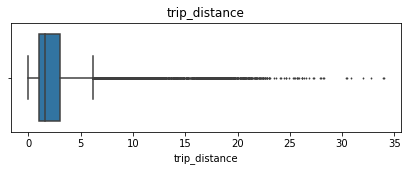

In [8]:
# Create box plot of trip_distance
#==> ENTER YOUR CODE HERE
plt.figure(figsize=(7, 2))
plt.title('trip_distance')
sns.boxplot(x=df['trip_distance'], flierprops={'markersize': 1})
plt.show()

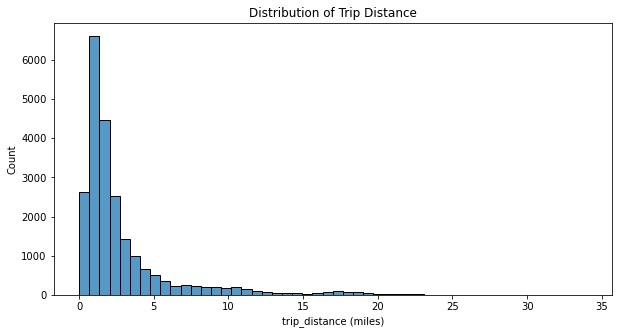

In [9]:
# Create histogram of trip_distance
#==> ENTER YOUR CODE HERE
plt.figure(figsize=(10, 5))
sns.histplot(df['trip_distance'], bins=50, kde=False)
plt.title('Distribution of Trip Distance')
plt.xlabel('trip_distance (miles)')
plt.ylabel('Count')
plt.show()

**total amount**

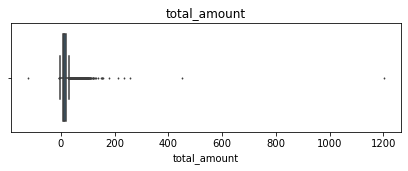

In [10]:
# Create box plot of total_amount
#==> ENTER YOUR CODE HERE
plt.figure(figsize=(7, 2))
plt.title('total_amount')
sns.boxplot(x=df['total_amount'], flierprops={'markersize': 1})
plt.show()

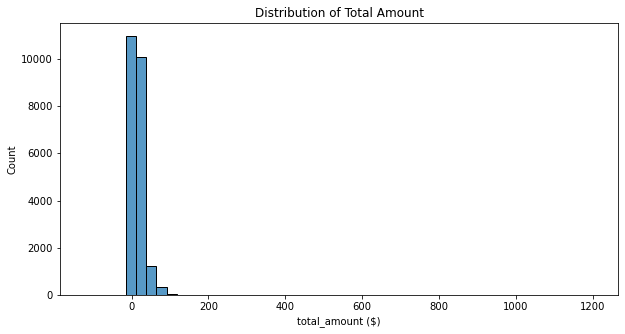

In [11]:
# Create histogram of total_amount
#==> ENTER YOUR CODE HERE
plt.figure(figsize=(10, 5))
sns.histplot(df['total_amount'], bins=50, kde=False)
plt.title('Distribution of Total Amount')
plt.xlabel('total_amount ($)')
plt.ylabel('Count')
plt.show()

**tip amount**

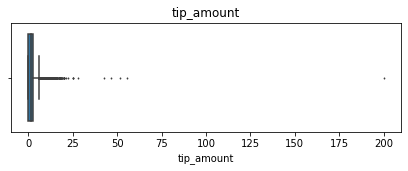

In [12]:
# Create box plot of tip_amount
#==> ENTER YOUR CODE HERE
plt.figure(figsize=(7, 2))
plt.title('tip_amount')
sns.boxplot(x=df['tip_amount'], flierprops={'markersize': 1})
plt.show()

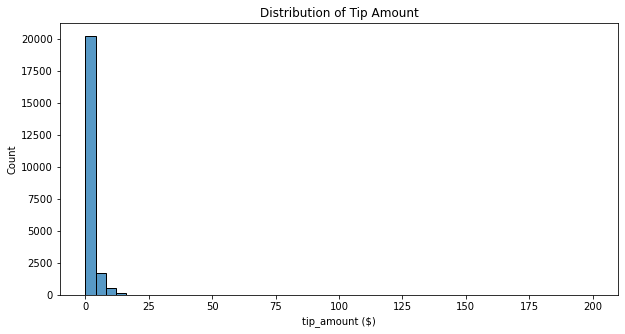

In [13]:
# Create histogram of tip_amount
#==> ENTER YOUR CODE HERE
plt.figure(figsize=(10, 5))
sns.histplot(df['tip_amount'], bins=50, kde=False)
plt.title('Distribution of Tip Amount')
plt.xlabel('tip_amount ($)')
plt.ylabel('Count')
plt.show()

**tip_amount by vendor**

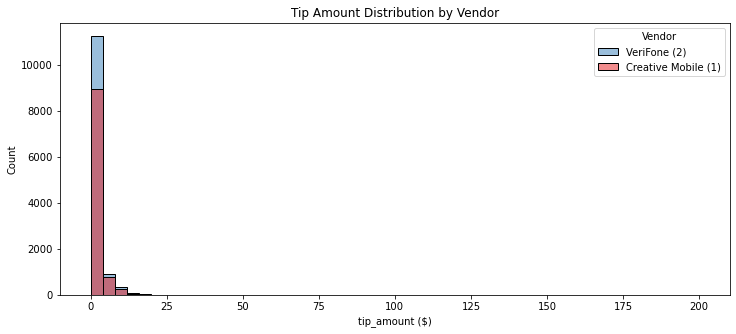

In [14]:
# Create histogram of tip_amount by vendor
#==> ENTER YOUR CODE HERE
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='tip_amount', hue='VendorID', bins=50, kde=False, palette='Set1')
plt.title('Tip Amount Distribution by Vendor')
plt.xlabel('tip_amount ($)')
plt.ylabel('Count')
plt.legend(title='Vendor', labels=['VeriFone (2)', 'Creative Mobile (1)'])
plt.show()

Next, zoom in on the upper end of the range of tips to check whether vendor one gets noticeably more of the most generous tips.

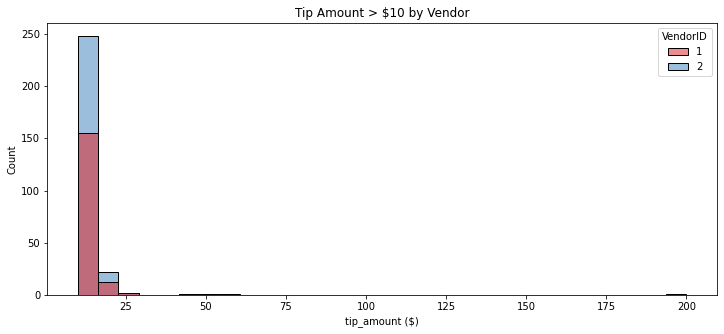

In [15]:
# Create histogram of tip_amount by vendor for tips > $10 
#==> ENTER YOUR CODE HERE
tips_over10 = df[df['tip_amount'] > 10]
plt.figure(figsize=(12, 5))
sns.histplot(data=tips_over10, x='tip_amount', hue='VendorID', bins=30, kde=False, palette='Set1')
plt.title('Tip Amount > $10 by Vendor')
plt.xlabel('tip_amount ($)')
plt.ylabel('Count')
plt.show()

**Mean tips by passenger count**

Examine the unique values in the `passenger_count` column.

In [16]:
#==> ENTER YOUR CODE HERE
df['passenger_count'].value_counts().sort_index()

0       33
1    16117
2     3305
3      953
4      455
5     1143
6      693
Name: passenger_count, dtype: int64

In [17]:
# Calculate mean tips by passenger_count
#==> ENTER YOUR CODE HERE
mean_tips_by_pax = df.groupby('passenger_count')['tip_amount'].mean().reset_index()
mean_tips_by_pax

,passenger_count,tip_amount
0,0,2.135758
1,1,1.848920
2,2,1.856378
3,3,1.716768
4,4,1.530264
5,5,1.873185
6,6,1.720260


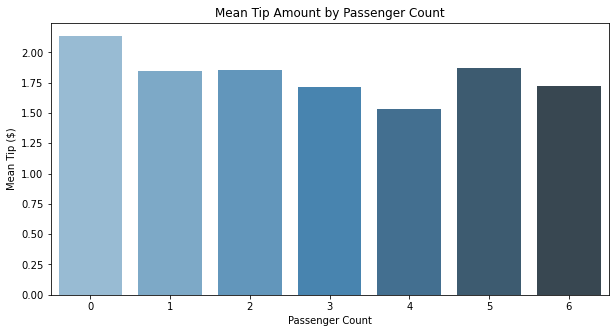

In [18]:
# Create bar plot for mean tips by passenger count
#==> ENTER YOUR CODE HERE
plt.figure(figsize=(10, 5))
sns.barplot(data=mean_tips_by_pax, x='passenger_count', y='tip_amount', palette='Blues_d')
plt.title('Mean Tip Amount by Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Mean Tip ($)')
plt.show()

**Create month and day columns**

In [19]:
# Create a month column
#==> ENTER YOUR CODE HERE
df['month'] = df['tpep_pickup_datetime'].dt.month_name()

# Create a day column
#==> ENTER YOUR CODE HERE
df['day'] = df['tpep_pickup_datetime'].dt.day_name()


**Plot total ride count by month**

Begin by calculating total ride count by month.

In [20]:
# Get total number of rides for each month
#==> ENTER YOUR CODE HERE
monthly_rides = df['month'].value_counts()

Reorder the results to put the months in calendar order.

In [21]:
# Reorder the monthly ride list so months go in order
#==> ENTER YOUR CODE HERE
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
monthly_rides = monthly_rides.reindex(month_order)

In [22]:
# Show the index
#==> ENTER YOUR CODE HERE
monthly_rides

January      1997
February     1769
March        2049
April        2019
May          2013
June         1964
July         1697
August       1724
September    1734
October      2027
November     1843
December     1863
Name: month, dtype: int64

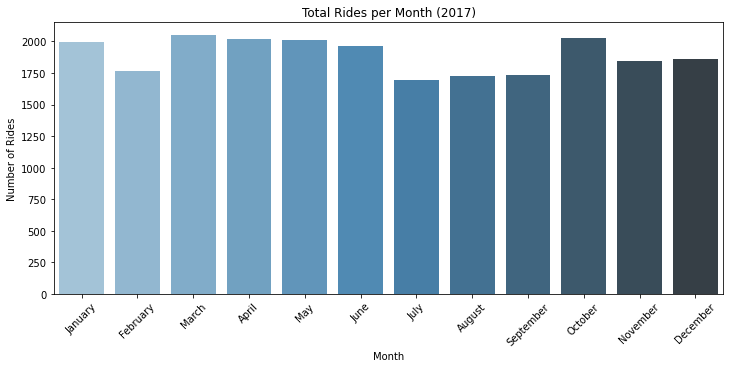

In [23]:
# Create a bar plot of total rides per month
#==> ENTER YOUR CODE HERE
plt.figure(figsize=(12, 5))
sns.barplot(x=monthly_rides.index, y=monthly_rides.values, palette='Blues_d')
plt.title('Total Rides per Month (2017)')
plt.xlabel('Month')
plt.ylabel('Number of Rides')
plt.xticks(rotation=45)
plt.show()

**Plot total ride count by day**

Repeat the above process, but now calculate the total rides by day of the week.

In [24]:
# Repeat the above process, this time for rides by day
#==> ENTER YOUR CODE HERE
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily_rides = df['day'].value_counts().reindex(day_order)

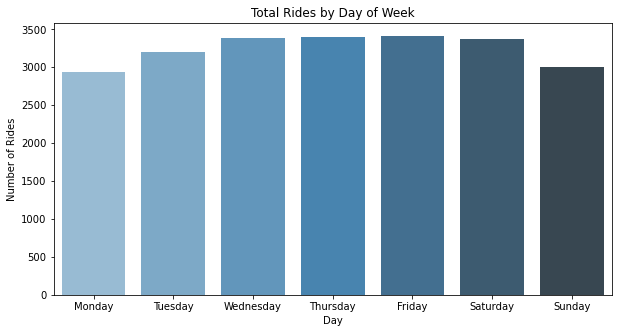

In [25]:
# Create bar plot for ride count by day
#==> ENTER YOUR CODE HERE
plt.figure(figsize=(10, 5))
sns.barplot(x=daily_rides.index, y=daily_rides.values, palette='Blues_d')
plt.title('Total Rides by Day of Week')
plt.xlabel('Day')
plt.ylabel('Number of Rides')
plt.show()

**Plot total revenue by day of the week**

Repeat the above process, but now calculate the total revenue by day of the week.

In [26]:
# Repeat the process, this time for total revenue by day
#==> ENTER YOUR CODE HERE
daily_revenue = df.groupby('day')['total_amount'].sum().reindex(day_order)

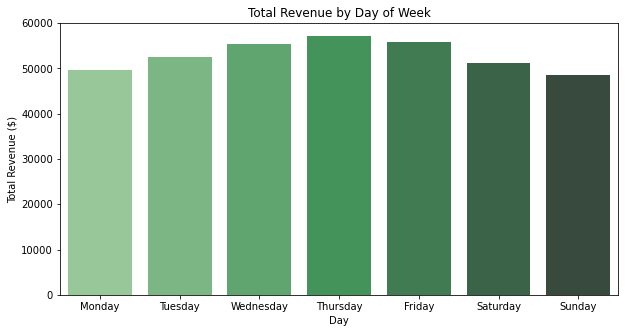

In [27]:
# Create bar plot of total revenue by day
#==> ENTER YOUR CODE HERE
plt.figure(figsize=(10, 5))
sns.barplot(x=daily_revenue.index, y=daily_revenue.values, palette='Greens_d')
plt.title('Total Revenue by Day of Week')
plt.xlabel('Day')
plt.ylabel('Total Revenue ($)')
plt.show()

**Plot total revenue by month**

In [28]:
# Repeat the process, this time for total revenue by month
#==> ENTER YOUR CODE HERE
monthly_revenue = df.groupby('month')['total_amount'].sum().reindex(month_order)

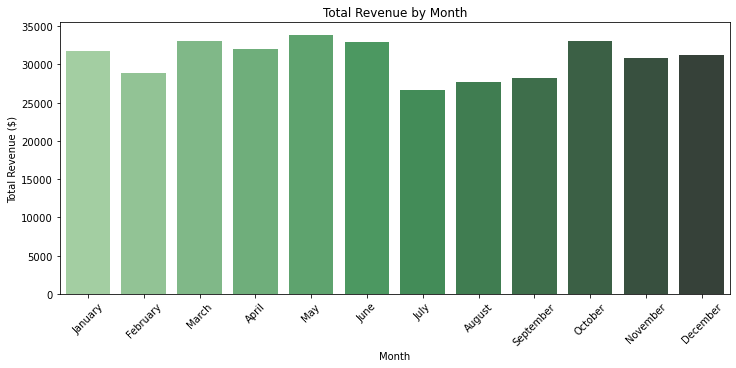

In [29]:
# Create a bar plot of total revenue by month
#==> ENTER YOUR CODE HERE
plt.figure(figsize=(12, 5))
sns.barplot(x=monthly_revenue.index, y=monthly_revenue.values, palette='Greens_d')
plt.title('Total Revenue by Month')
plt.xlabel('Month')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.show()

#### Scatter plot

You can create a scatterplot in Tableau Public, which can be easier to manipulate and present. If you'd like step by step instructions, you can review the following link. Those instructions create a scatterplot showing the relationship between total_amount and trip_distance. Consider adding the Tableau visualization to your executive summary, and adding key insights from your findings on those two variables.

[Tableau visualization guidelines](https://docs.google.com/document/d/1pcfUlttD2Y_a9A4VrKPzikZWCAfFLsBAhuKuomjcUjA/template/preview)

**Plot mean trip distance by drop-off location**

In [30]:
# Get number of unique drop-off location IDs
#==> ENTER YOUR CODE HERE
df['DOLocationID'].nunique()

216

In [31]:
# Calculate the mean trip distance for each drop-off location
#==> ENTER YOUR CODE HERE
mean_dist_by_dropoff = df.groupby('DOLocationID')['trip_distance'].mean()

# Sort the results in descending order by mean trip distance
#==> ENTER YOUR CODE HERE
mean_dist_by_dropoff = mean_dist_by_dropoff.sort_values(ascending=False)
mean_dist_by_dropoff.head(10)


DOLocationID
23     24.275000
29     21.650000
210    20.500000
11     17.945000
51     17.310000
1      17.027353
219    16.900000
86     16.000000
259    15.886667
183    15.720000
Name: trip_distance, dtype: float64

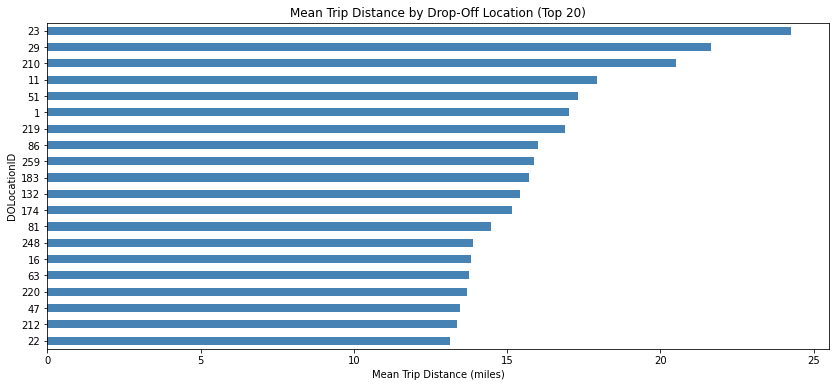

In [32]:
# Create a bar plot of mean trip distances by drop-off location in ascending order by distance
#==> ENTER YOUR CODE HERE
top20 = mean_dist_by_dropoff.sort_values(ascending=True).tail(20)
plt.figure(figsize=(14, 6))
top20.plot(kind='barh', color='steelblue')
plt.title('Mean Trip Distance by Drop-Off Location (Top 20)')
plt.xlabel('Mean Trip Distance (miles)')
plt.ylabel('DOLocationID')
plt.show()

## BONUS CONTENT

To confirm your conclusion, consider the following experiment:
1. Create a sample of coordinates from a normal distribution&mdash;in this case 1,500 pairs of points from a normal distribution with a mean of 10 and a standard deviation of 5
2. Calculate the distance between each pair of coordinates 
3. Group the coordinates by endpoint and calculate the mean distance between that endpoint and all other points it was paired with
4. Plot the mean distance for each unique endpoint

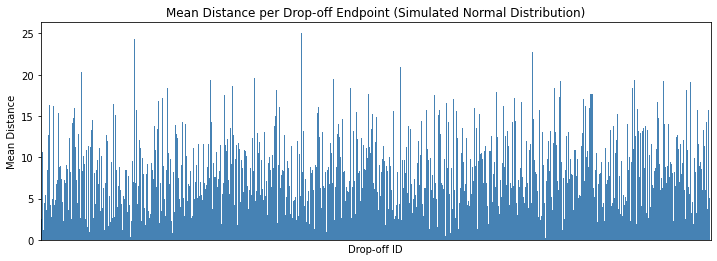

In [33]:
#BONUS CONTENT

#1. Generate random points on a 2D plane from a normal distribution
#==> ENTER YOUR CODE HERE
np.random.seed(42)
coords = np.random.normal(loc=10, scale=5, size=(1500, 2))

# 2. Calculate Euclidean distances between points in first half and second half of array
#==> ENTER YOUR CODE HERE
distances = np.sqrt(((coords[:750] - coords[750:]) ** 2).sum(axis=1))

# 3. Group the coordinates by "drop-off location", compute mean distance
#==> ENTER YOUR CODE HERE
dropoff_ids = np.arange(750)
mean_distances = pd.Series(distances, index=dropoff_ids).reset_index()
mean_distances.columns = ['dropoff_id', 'distance']
mean_dist_grouped = mean_distances.groupby('dropoff_id')['distance'].mean()

# 4. Plot the mean distance between each endpoint ("drop-off location") and all points it connected to
#==> ENTER YOUR CODE HERE
plt.figure(figsize=(12, 4))
mean_dist_grouped.plot(kind='bar', color='steelblue', width=1.0)
plt.title('Mean Distance per Drop-off Endpoint (Simulated Normal Distribution)')
plt.xlabel('Drop-off ID')
plt.ylabel('Mean Distance')
plt.xticks([])
plt.show()


**Histogram of rides by drop-off location**

First, check to whether the drop-off locations IDs are consecutively numbered. For instance, does it go 1, 2, 3, 4..., or are some numbers missing (e.g., 1, 3, 4...). If numbers aren't all consecutive, the histogram will look like some locations have very few or no rides when in reality there's no bar because there's no location. 

In [34]:
# Check if all drop-off locations are consecutively numbered
#==> ENTER YOUR CODE HERE
sorted_locs = sorted(df['DOLocationID'].unique())
print(f"Min: {min(sorted_locs)}, Max: {max(sorted_locs)}, Unique count: {len(sorted_locs)}")
print("Consecutive?", sorted_locs == list(range(min(sorted_locs), max(sorted_locs)+1)))

Min: 1, Max: 265, Unique count: 216
Consecutive? False


To eliminate the spaces in the historgram that these missing numbers would create, sort the unique drop-off location values, then convert them to strings. This will make the histplot function display all bars directly next to each other. 

In [35]:
#==> ENTER YOUR CODE HERE
# DOLocationID column is numeric, so sort in ascending order
#==> ENTER YOUR CODE HERE
print("Consecutive?", sorted_locs == list(range(min(sorted_locs), max(sorted_locs)+1)))

# Convert to string
#==> ENTER YOUR CODE HERE
df['DOLocationID_str'] = df['DOLocationID'].astype(str)

# Plot
#==> ENTER YOUR CODE HERE
plt.figure(figsize=(16, 4))
sns.histplot(data=df, x='DOLocationID_str', 
             order=[str(x) for x in sorted_dropoffs])
plt.title('Rides by Drop-Off Location')
plt.xlabel('Drop-Off Location ID')
plt.ylabel('Count')
plt.xticks([])  # Too many to label
plt.show()


Consecutive? False


NameError: name 'sorted_dropoffs' is not defined

<Figure size 1152x288 with 0 Axes>

<img src="images/Execute.png" width="100" height="100" align=left>

## PACE: Execute 

Consider the questions in your PACE Strategy Document to reflect on the Execute stage.

### Task 4a. Results and evaluation

Having built visualizations in Tableau and in Python, what have you learned about the dataset? What other questions have your visualizations uncovered that you should pursue? 

***Pro tip:*** Put yourself in your client's perspective, what would they want to know? 

Use the following code fields to pursue any additional EDA based on the visualizations you've already plotted. Also use the space to make sure your visualizations are clean, easily understandable, and accessible. 

***Ask yourself:*** Did you consider color, contrast, emphasis, and labeling?



==> ENTER YOUR RESPONSE HERE

ANSWER:

I have learned that trip volume peaks on Fridays and Thursdays, and revenue follows the same weekly pattern. March and October are the highest-revenue months. Most trips are short (under 3 miles) and cheap (under $15), but there is a significant right-skewed tail. Credit card payments dominate (~67%), and tip data is only reliable for credit card transactions — cash tips are not captured. VeriFone (Vendor 2) handles slightly more trips than Creative Mobile (Vendor 1), but tip distributions are similar between vendors.

My other questions are: Does surge pricing explain the high-fare outliers? Do drop-off zones near airports consistently produce longer trips? Is there a meaningful difference in fare rates between rate codes?

My client (NYC TLC) would likely want to know: Which zones generate the most revenue? What times of day/week drive peak demand? Are there zones or time periods where ride demand is underserved?



In [ ]:
#==> ENTER YOUR CODE HERE
# Optional: fare_amount distribution
plt.figure(figsize=(10, 5))
sns.histplot(df[df['fare_amount'] > 0]['fare_amount'], bins=50, kde=False)
plt.title('Distribution of Fare Amount (positive values only)')
plt.xlabel('Fare Amount ($)')
plt.show()

In [ ]:
#==> ENTER YOUR CODE HERE
# Optional: correlation heatmap of numeric columns
numeric_cols = ['trip_distance', 'fare_amount', 'tip_amount', 'total_amount', 
                'passenger_count', 'tolls_amount']
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='Blues')
plt.title('Correlation Matrix')
plt.show()

### Task 4b. Conclusion
*Make it professional and presentable*

You have visualized the data you need to share with the director now. Remember, the goal of a data visualization is for an audience member to glean the information on the chart in mere seconds.

*Questions to ask yourself for reflection:*
Why is it important to conduct Exploratory Data Analysis? Why are the data visualizations provided in this notebook useful?



EDA is important because ... 
==> ENTER YOUR RESPONSE HERE

ANSWER:

It reveals the structure, quality, and distribution of the data before any modeling begins. Without EDA, we risk building a model on dirty data — including negative fares, zero-distance trips, and extreme outliers — which would produce unreliable predictions. 
EDA also helps identify which variables are most relevant and what feature engineering is needed.




Visualizations helped me understand ..
==> ENTER YOUR RESPONSE HERE

ANSWER:

The relationship between trip distance and fare, the temporal patterns in ride demand, and the distribution of tips by vendor and payment type. Bar charts made it immediately clear that Friday is the busiest and most profitable day, and histograms confirmed the heavy right skew in fare and distance — both important facts for choosing the right regression approach.




You’ve now completed professional data visualizations according to a business need. Well done! 

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.